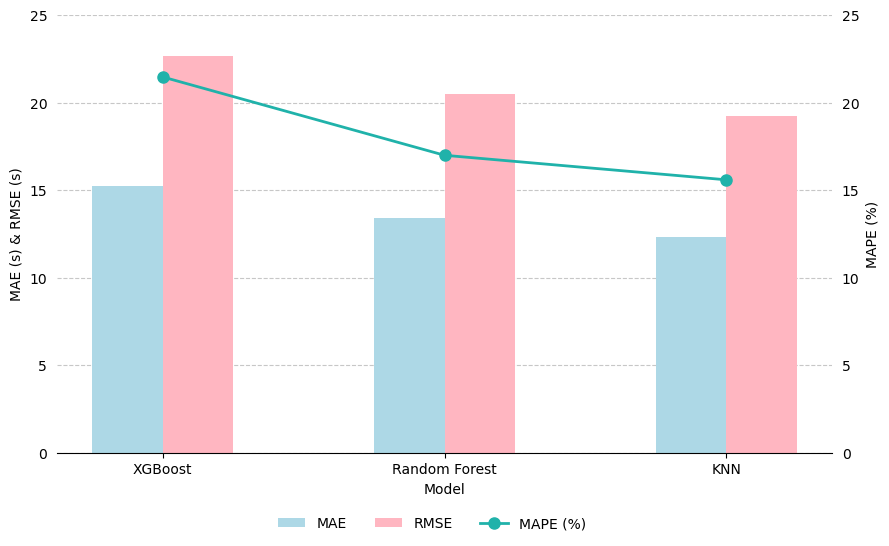

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

models = ['XGBoost', 'Random Forest', 'KNN']
mae = [15.23, 13.40, 12.33]
rmse = [22.65, 20.46, 19.23]
mape = [21.46, 16.99, 15.59]

df = pd.DataFrame({
    'Model': models,
    'MAE': mae,
    'RMSE': rmse,
    'MAPE (%)': mape
})
df

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_axisbelow(True)

width = 0.25

x = np.arange(len(models))

bars1 = ax1.bar(x - width/2, mae, width, label='MAE', color='#ADD8E6')
bars2 = ax1.bar(x + width/2, rmse, width, label='RMSE', color='#FFB6C1')

ax1.set_xlabel('Model')
ax1.set_ylabel('MAE (s) & RMSE (s)')
ax1.set_xticks(x)
ax1.set_xticklabels(models)

ax2 = ax1.twinx()
ax2.set_axisbelow(True)

line, = ax2.plot(x, mape, color='lightseagreen', marker='o', linestyle='-', 
                 linewidth=2, markersize=8, label='MAPE (%)')

ax2.set_ylabel('MAPE (%)')

ax1.set_ylim(0, 25)
ax2.set_ylim(0, 25)

ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.tick_params(axis='y', left=False)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.tick_params(axis='y', right=False)

handles = [bars1, bars2, line]

fig.legend(handles=[bars1, bars2, line], 
           labels=['MAE', 'RMSE', 'MAPE (%)'],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.0),
           frameon=False,
           ncol=3)

plt.subplots_adjust(bottom=0.15)
plt.savefig('Results/overall_comparison_plot.pdf')

plt.show()

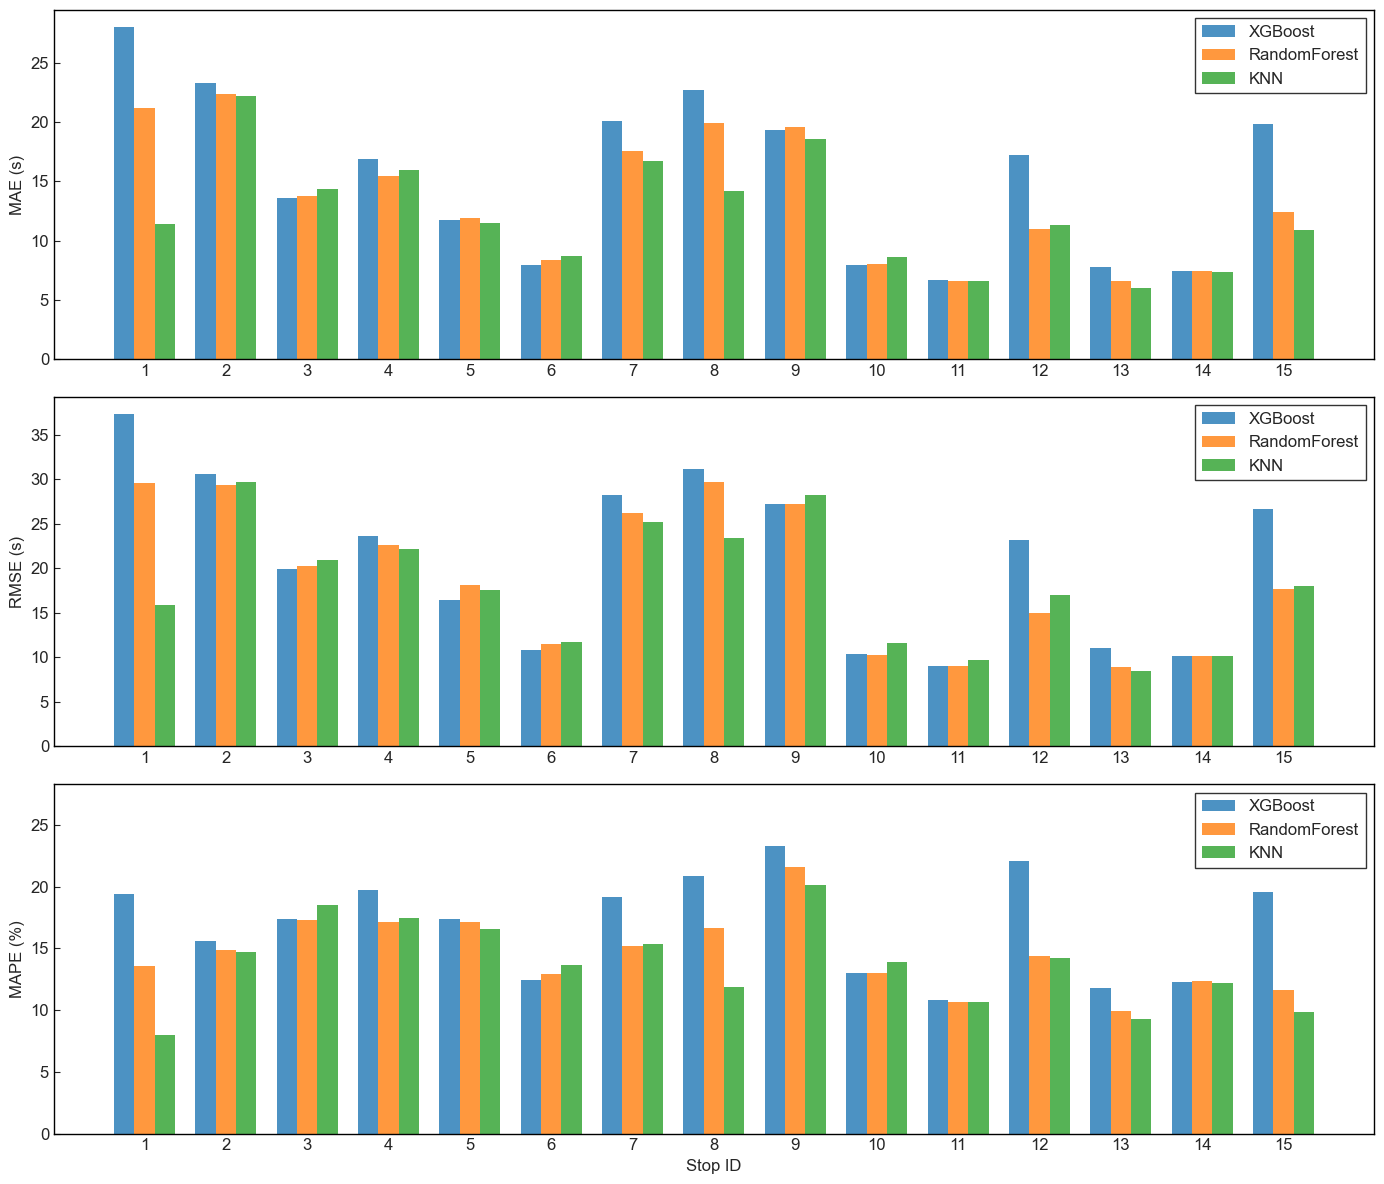

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 10)

# Load CSV files
mae_df = pd.read_csv('compare_mae_ml.csv')
mape_df = pd.read_csv('compare_mape_ml.csv')
rmse_df = pd.read_csv('compare_rmse_ml.csv')

# Create figure and subplots (order: MAE, RMSE, MAPE)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Define colors and model labels
models = ['XGBoost', 'RandomForest', 'KNN']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# Common x positions
x = np.arange(len(mae_df['STOP']))  # stop positions (0,1,...,14)
width = 0.25  # bar width

# --- Plot MAE (top) ---
ax = axes[0]
for i, model in enumerate(models):
    ax.bar(x + i*width, mae_df[model], width, label=model, color=colors[i], alpha=0.8)

ax.set_ylabel('MAE (s)')
ax.set_xticks(x + width)
ax.set_xticklabels(mae_df['STOP'])  # stop numbers 1-15
ax.xaxis.set_tick_params(labelbottom=True)  # show x-axis labels on this subplot
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)  # legend with border
ax.grid(False)  # Remove grid lines
ax.tick_params(axis='y', which='both', length=4, direction='in')  # y-axis ticks visible

# --- Plot RMSE (middle) ---
ax = axes[1]
for i, model in enumerate(models):
    ax.bar(x + i*width, rmse_df[model], width, label=model, color=colors[i], alpha=0.8)

ax.set_ylabel('RMSE (s)')
ax.set_xticks(x + width)
ax.set_xticklabels(mae_df['STOP'])
ax.xaxis.set_tick_params(labelbottom=True)  # show x-axis labels on this subplot
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)  # legend with border
ax.grid(False)  # Remove grid lines
ax.tick_params(axis='y', which='both', length=4, direction='in')  # y-axis ticks visible

# --- Plot MAPE (bottom) ---
ax = axes[2]
for i, model in enumerate(models):
    ax.bar(x + i*width, mape_df[model], width, label=model, color=colors[i], alpha=0.8)

ax.set_ylabel('MAPE (%)')
ax.set_xlabel('Stop ID')
ax.set_xticks(x + width)
ax.set_xticklabels(mae_df['STOP'])
ax.xaxis.set_tick_params(labelbottom=True)  # already True by default, but explicit
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)  # legend with border
ax.grid(False)  # Remove grid lines
ax.tick_params(axis='y', which='both', length=4, direction='in')  # y-axis ticks visible

# Set MAPE y-axis limit to max value + 5
max_mape = max(mape_df[models].max())  # get the maximum value across all models
ax.set_ylim(0, max_mape + 5)  # extend upper limit by 5

# Ensure all subplots have visible borders (black, linewidth=1)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.savefig('Results/stations_comparison_plot.pdf')
plt.show()

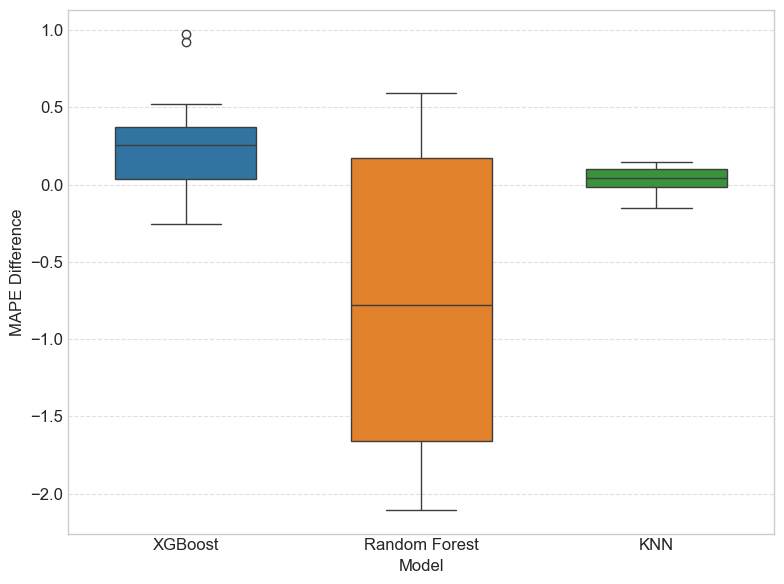

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('difference.csv')

df_melted = df.melt(id_vars='stop',
                    value_vars=['XGBoost', 'Random Forest', 'KNN'],
                    var_name='Model',
                    value_name='MAPE_Diff')

palette = {
    'XGBoost': '#1f77b4',
    'Random Forest': '#ff7f0e',
    'KNN': '#2ca02c'
}

plt.figure(figsize=(8, 6))

ax = sns.boxplot(x='Model', y='MAPE_Diff', data=df_melted,
                 hue='Model', palette=palette, width=0.6,
                 legend=False)

plt.xlabel('Model')
plt.ylabel('MAPE Difference')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Results/station_MAPE_differences.pdf')
plt.show()